# BGL Log Feature Extraction (Assignment Part 2)

This notebook uses the **BGL.log** dataset and applies **three substantially different feature extraction methods**:
1. Manual structured features (required manual method for text logs).
2. Template-based event features (message normalization + template IDs/frequencies).
3. TF-IDF text features (for downstream classification).

Requirement coverage:
- At least one visualization: manual and text-feature visualizations are included.
- At least one downstream classifier: logistic regression is trained on TF-IDF features.

In [3]:
from pathlib import Path
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

project_root = Path.cwd()
if not (project_root / 'BGL.log').exists():
    project_root = project_root.parent

log_path = project_root / 'BGL.log'
if not log_path.exists():
    raise FileNotFoundError(f'BGL.log not found from resolved root: {project_root}')

artifacts_dir = project_root / 'artifacts' / 'bgl_log_feature_extraction'
artifacts_dir.mkdir(parents=True, exist_ok=True)

SAMPLE_SIZE = 300_000
MAX_CLASSIFICATION_ROWS = 200_000

print('Project root:', project_root)
print('Log path:', log_path)
print('Artifacts dir:', artifacts_dir)

Project root: /Users/sidqian/Downloads/Code/log-ml
Log path: /Users/sidqian/Downloads/Code/log-ml/BGL.log
Artifacts dir: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction


In [4]:
def reservoir_sample_lines(path: Path, sample_size: int, seed: int = 42):
    rng = random.Random(seed)
    sample = []
    total = 0

    with path.open('r', errors='ignore') as f:
        for total, line in enumerate(f, start=1):
            line = line.rstrip('\n')
            if total <= sample_size:
                sample.append(line)
            else:
                j = rng.randint(1, total)
                if j <= sample_size:
                    sample[j - 1] = line

    return sample, total

raw_lines, total_lines = reservoir_sample_lines(log_path, SAMPLE_SIZE, seed=42)

print(f'Total lines scanned: {total_lines:,}')
print(f'Sampled lines used in notebook: {len(raw_lines):,}')
print('Sample line 1:', raw_lines[0][:160])

Total lines scanned: 4,747,963
Sampled lines used in notebook: 300,000
Sample line 1: - 1119695642 2005.06.25 R30-M0-N7-C:J11-U01 2005-06-25-03.34.02.918500 R30-M0-N7-C:J11-U01 RAS KERNEL INFO 257923536 double-hummer alignment exceptions


In [5]:
def parse_bgl_line(line: str):
    parts = line.split(' ', 9)
    if len(parts) < 10:
        return None

    return {
        'label': parts[0],
        'unix_ts': parts[1],
        'date_token': parts[2],
        'location': parts[3],
        'timestamp_text': parts[4],
        'location_dup': parts[5],
        'facility': parts[6],
        'component': parts[7],
        'level': parts[8],
        'message': parts[9],
    }

records = []
for line in raw_lines:
    rec = parse_bgl_line(line)
    if rec is not None:
        records.append(rec)

df = pd.DataFrame(records)
df['unix_ts'] = pd.to_numeric(df['unix_ts'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp_text'], format='%Y-%m-%d-%H.%M.%S.%f', errors='coerce')
df['is_anomaly'] = (df['label'] != '-').astype(int)

print(f'Parsed rows: {len(df):,} / {len(raw_lines):,}')
print('Anomaly distribution (0=normal,1=anomaly):')
print(df['is_anomaly'].value_counts(normalize=True).rename('ratio'))
df.head(5)

Parsed rows: 297,834 / 300,000
Anomaly distribution (0=normal,1=anomaly):
is_anomaly
0    0.926053
1    0.073947
Name: ratio, dtype: float64


,label,unix_ts,date_token,location,timestamp_text,location_dup,facility,component,level,message,timestamp,is_anomaly
0,-,1119695642,2005.06.25,R30-M0-N7-C:J11-U01,2005-06-25-03.34.02.918500,R30-M0-N7-C:J11-U01,RAS,KERNEL,INFO,257923536 double-hummer alignment exceptions,2005-06-25 03:34:02.918500,0
1,-,1120929206,2005.07.09,R12-M1-N6-C:J13-U01,2005-07-09-10.13.26.900784,R12-M1-N6-C:J13-U01,RAS,KERNEL,INFO,generating core.8437,2005-07-09 10:13:26.900784,0
2,-,1127243365,2005.09.20,NULL,2005-09-20-12.09.25.304629,NULL,RAS,MMCS,ERROR,idoproxydb hit ASSERT condition: ASSERT expres...,2005-09-20 12:09:25.304629,0
3,-,1133011729,2005.11.26,R22-M0-N4-I:J18-U01,2005-11-26-05.28.49.225106,R22-M0-N4-I:J18-U01,RAS,KERNEL,INFO,"ciod: Received signal 15, code=0, errno=0, add...",2005-11-26 05:28:49.225106,0
4,-,1120172389,2005.06.30,R03-M0-NB-C:J10-U11,2005-06-30-15.59.49.329370,R03-M0-NB-C:J10-U11,RAS,KERNEL,INFO,41 ddr errors(s) detected and corrected on ran...,2005-06-30 15:59:49.329370,0


## Method 1: Manual Structured Feature Extraction
Manual features include lexical, temporal, and system-pattern indicators from each log line.

In [6]:
df['message_length'] = df['message'].str.len().fillna(0).astype(int)
df['message_token_count'] = df['message'].str.split().str.len().fillna(0).astype(int)

df['hour'] = df['timestamp'].dt.hour.fillna(-1).astype(int)
df['dayofweek'] = df['timestamp'].dt.dayofweek.fillna(-1).astype(int)

df['has_digit'] = df['message'].str.contains(r'\d', regex=True, na=False).astype(int)
df['has_hex_like'] = df['message'].str.contains(r'0x|[A-Fa-f0-9]{8,}', regex=True, na=False).astype(int)
df['has_cache_word'] = df['message'].str.contains(r'cache|tlb|l1|l2', regex=True, case=False, na=False).astype(int)
df['has_memory_word'] = df['message'].str.contains(r'memory|parity|ecc', regex=True, case=False, na=False).astype(int)
df['has_network_word'] = df['message'].str.contains(r'torus|link|packet|network', regex=True, case=False, na=False).astype(int)

df['level_code'] = pd.factorize(df['level'])[0]
df['facility_code'] = pd.factorize(df['facility'])[0]
df['component_code'] = pd.factorize(df['component'])[0]

manual_feature_cols = [
    'message_length', 'message_token_count',
    'hour', 'dayofweek',
    'has_digit', 'has_hex_like', 'has_cache_word', 'has_memory_word', 'has_network_word',
    'level_code', 'facility_code', 'component_code'
]

df[manual_feature_cols + ['is_anomaly']].head(10)

,message_length,message_token_count,hour,dayofweek,has_digit,has_hex_like,has_cache_word,has_memory_word,has_network_word,level_code,facility_code,component_code,is_anomaly
0,44,4,3,5,1,1,0,0,0,0,0,0,0
1,20,2,10,5,1,0,0,0,0,0,0,0,0
2,171,13,12,1,1,0,0,0,1,1,0,1,0
3,61,7,5,5,1,1,0,0,0,0,0,0,0
4,67,13,15,3,1,0,0,0,0,0,0,0,0
5,40,5,16,3,0,0,1,1,0,0,0,0,0
6,20,2,20,2,1,0,0,0,0,0,0,0,0
7,41,5,17,3,1,0,0,0,0,0,0,0,0
8,21,2,19,1,1,0,0,0,0,0,0,0,0
9,20,2,8,5,1,0,0,0,0,0,0,0,0


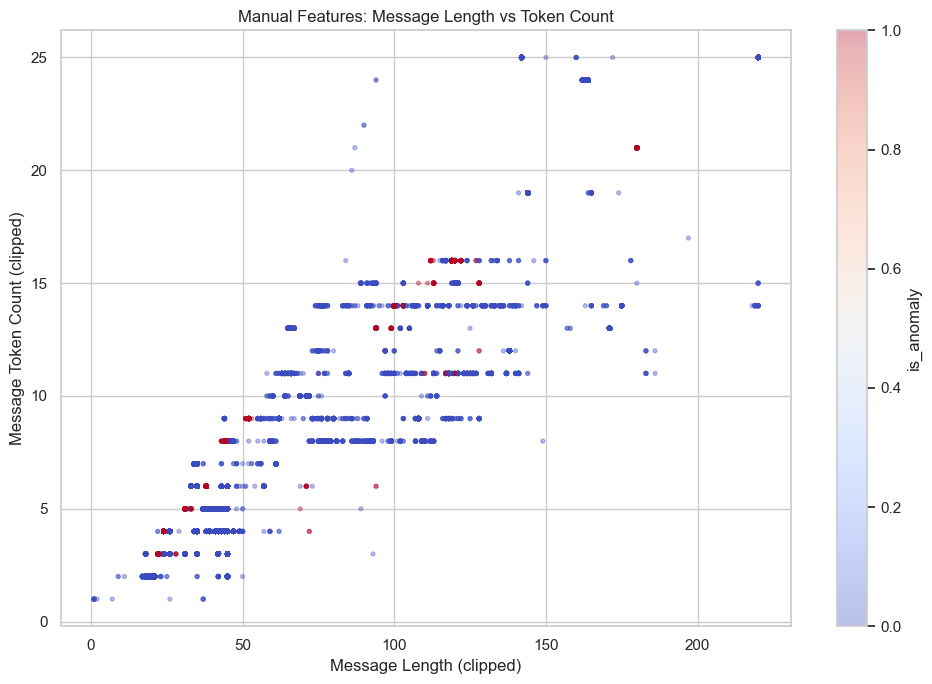

Saved manual-feature visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction/bgl_manual_feature_scatter.png


In [7]:
# Visualization requirement (using manual features)
plot_df = df.sample(min(50000, len(df)), random_state=42)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    plot_df['message_length'].clip(upper=plot_df['message_length'].quantile(0.99)),
    plot_df['message_token_count'].clip(upper=plot_df['message_token_count'].quantile(0.99)),
    c=plot_df['is_anomaly'],
    cmap='coolwarm',
    s=8,
    alpha=0.35,
)
plt.colorbar(scatter, label='is_anomaly')
plt.title('Manual Features: Message Length vs Token Count')
plt.xlabel('Message Length (clipped)')
plt.ylabel('Message Token Count (clipped)')
plt.tight_layout()

manual_viz_path = artifacts_dir / 'bgl_manual_feature_scatter.png'
plt.savefig(manual_viz_path, dpi=180, bbox_inches='tight')
plt.show()

print('Saved manual-feature visualization to:', manual_viz_path)

## Method 2: Template-Based Feature Extraction
Messages are normalized into templates by masking variable tokens (numbers, hex patterns, IDs).

In [8]:
def normalize_template(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'0x[0-9a-f]+', '<hex>', text)
    text = re.sub(r'\b\d+\b', '<num>', text)
    text = re.sub(r'r\d+-m\d+-n\d+(?:-[a-z]:[a-z]\d+-u\d+)?', '<node>', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['message_template'] = df['message'].map(normalize_template)
df['template_id'] = pd.factorize(df['message_template'])[0]
template_counts = df['template_id'].value_counts()
df['template_frequency'] = df['template_id'].map(template_counts).astype(int)

top_templates = (
    df[['template_id', 'message_template']]
    .drop_duplicates('template_id')
    .merge(template_counts.rename('count'), left_on='template_id', right_index=True)
    .sort_values('count', ascending=False)
    .head(15)
)

print('Unique templates:', df['template_id'].nunique())
top_templates

Unique templates: 10293


,template_id,message_template,count
1,1,generating core.<num>,107669
0,0,<num> double-hummer alignment exceptions,18582
7,6,<num> floating point alignment exceptions,16907
22,10,"ce sym <num>, at <hex>, mask <hex>",12705
69,27,data tlb error interrupt,9658
43,18,<num> microseconds spent in the rbs signal han...,8550
15,7,<num> total interrupts. <num> critical input i...,8405
5,5,instruction cache parity error corrected,6738
2,2,idoproxydb hit assert condition: assert expres...,5317
36,16,data storage interrupt,4035


## Method 3: TF-IDF Text Features
Use TF-IDF for downstream classification and 2D SVD projection for text-space interpretation.

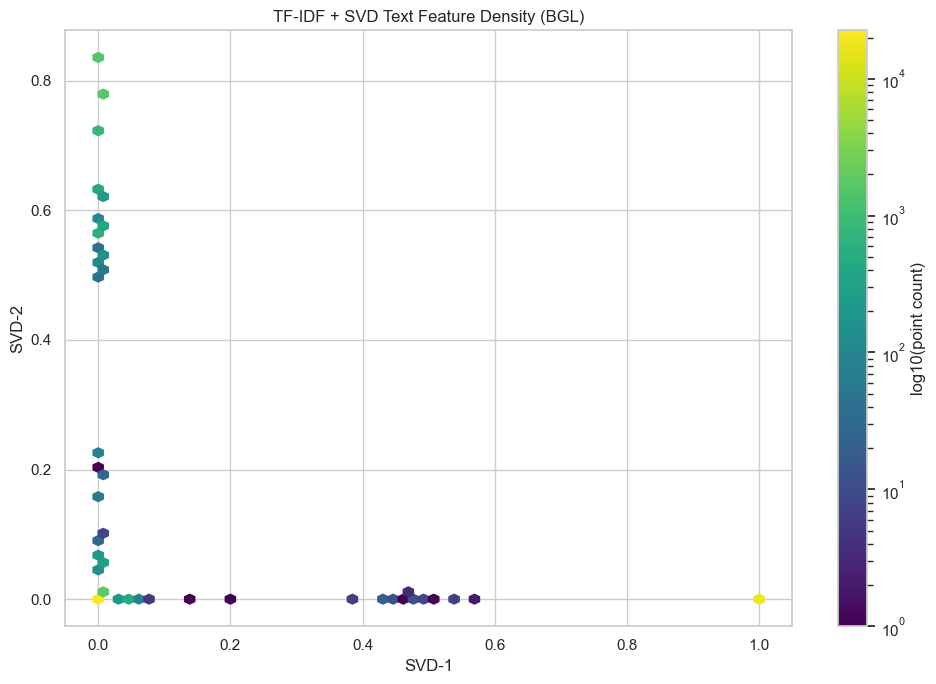

SVD explained variance ratio: [0.27044148 0.0646679 ]
Saved text-feature visualization to: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction/bgl_tfidf_svd_density.png


In [9]:
text_for_viz = df['message'].fillna('')
tfidf_viz = TfidfVectorizer(max_features=1200, min_df=3, ngram_range=(1, 2), stop_words='english')
X_viz = tfidf_viz.fit_transform(text_for_viz)

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_viz)

plot2_df = pd.DataFrame({'x': X_2d[:, 0], 'y': X_2d[:, 1], 'is_anomaly': df['is_anomaly'].to_numpy()})
plot2_df = plot2_df.sample(min(50000, len(plot2_df)), random_state=42)

plt.figure(figsize=(10, 7))
hb = plt.hexbin(plot2_df['x'], plot2_df['y'], gridsize=65, bins='log', mincnt=1, cmap='viridis')
plt.colorbar(hb, label='log10(point count)')
plt.title('TF-IDF + SVD Text Feature Density (BGL)')
plt.xlabel('SVD-1')
plt.ylabel('SVD-2')
plt.tight_layout()

tfidf_viz_path = artifacts_dir / 'bgl_tfidf_svd_density.png'
plt.savefig(tfidf_viz_path, dpi=180, bbox_inches='tight')
plt.show()

print('SVD explained variance ratio:', svd.explained_variance_ratio_)
print('Saved text-feature visualization to:', tfidf_viz_path)

In [12]:
# Classification requirement using TF-IDF features
clf_df = df[['message', 'is_anomaly']].dropna().copy()
if len(clf_df) > MAX_CLASSIFICATION_ROWS:
    clf_df = clf_df.sample(MAX_CLASSIFICATION_ROWS, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    clf_df['message'],
    clf_df['is_anomaly'],
    test_size=0.2,
    random_state=42,
    stratify=clf_df['is_anomaly']
)

clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=3, ngram_range=(1, 2), stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

clf_pipeline.fit(X_train, y_train)
pred = clf_pipeline.predict(X_test)
proba = clf_pipeline.predict_proba(X_test)[:, 1]

print('F1 score:', f1_score(y_test, pred))
print('ROC-AUC:', roc_auc_score(y_test, proba))
print('Confusion matrix:\n', confusion_matrix(y_test, pred))
print('Classification report:\n', classification_report(y_test, pred, digits=4))

F1 score: 0.997449413365074
ROC-AUC: 0.9999993931126228
Confusion matrix:
 [[37052    14]
 [    1  2933]]
Classification report:
               precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998     37066
           1     0.9952    0.9997    0.9974      2934

    accuracy                         0.9996     40000
   macro avg     0.9976    0.9996    0.9986     40000
weighted avg     0.9996    0.9996    0.9996     40000



In [13]:
# Export core feature table
final_features = df[[
    'label', 'is_anomaly', 'unix_ts', 'timestamp', 'location', 'facility', 'component', 'level', 'message',
    'message_length', 'message_token_count', 'hour', 'dayofweek',
    'has_digit', 'has_hex_like', 'has_cache_word', 'has_memory_word', 'has_network_word',
    'level_code', 'facility_code', 'component_code',
    'template_id', 'template_frequency'
]].copy()

features_path = artifacts_dir / 'bgl_log_features.csv'
final_features.to_csv(features_path, index=False)

sample_path = artifacts_dir / 'bgl_log_sample.csv'
df.head(1000).to_csv(sample_path, index=False)

print('Saved feature table to:', features_path)
print('Saved sample table to:', sample_path)
print('Final rows:', len(final_features))
print('Unique templates:', final_features['template_id'].nunique())

Saved feature table to: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction/bgl_log_features.csv
Saved sample table to: /Users/sidqian/Downloads/Code/log-ml/artifacts/bgl_log_feature_extraction/bgl_log_sample.csv
Final rows: 297834
Unique templates: 10293
